In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

**Task 1**

In [45]:
df=pd.read_csv("adult.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [46]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [47]:
print("Missing values: ", df.isnull().sum())

Missing values:  age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


In [48]:
df.replace("?", np.nan, inplace=True)

In [49]:
print("Missing values: ", df.isnull().sum())

Missing values:  age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


**Task 2**

In [50]:
print("Count of Missing Values per column")
print(df.isnull().sum().sort_values(ascending=False))

Count of Missing Values per column
occupation        1843
workclass         1836
native.country     583
fnlwgt               0
education            0
education.num        0
age                  0
marital.status       0
relationship         0
sex                  0
race                 0
capital.gain         0
capital.loss         0
hours.per.week       0
income               0
dtype: int64


In [51]:
#percentage of missing values
print("Percentage of Missing Values per column")
print(df.isnull().mean().sort_values(ascending=False)*100)

Percentage of Missing Values per column
occupation        5.660146
workclass         5.638647
native.country    1.790486
fnlwgt            0.000000
education         0.000000
education.num     0.000000
age               0.000000
marital.status    0.000000
relationship      0.000000
sex               0.000000
race              0.000000
capital.gain      0.000000
capital.loss      0.000000
hours.per.week    0.000000
income            0.000000
dtype: float64


Three columns have missing values: workclass, occupation, naitve country.

**Task 3**

In [52]:
#workclass and occupation

#for occuption ill keep it unknown
#for workclass ill keep it mode
df["workclass"].fillna(df["workclass"].mode()[0], inplace=True)
df["occupation"].fillna("Unknown", inplace=True)

/tmp/ipykernel_4937/992639129.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["workclass"].fillna(df["workclass"].mode()[0], inplace=True)
/tmp/ipykernel_4937/992639129.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

In [53]:
print("Count of Missing Values per column after replacing")
print(df.isnull().sum().sort_values(ascending=False))

Count of Missing Values per column after replacing
native.country    583
workclass           0
age                 0
education           0
education.num       0
marital.status      0
fnlwgt              0
occupation          0
relationship        0
sex                 0
race                0
capital.gain        0
capital.loss        0
hours.per.week      0
income              0
dtype: int64


The reason I went for Unknown in occupation is that occupation is really specific, and can easily vary from person to person, whereas for workclass the mode is more applicable and applied for broader positions.

**Task 4**

In [54]:
print("Duplicated Rows check: ")
print(df.duplicated().sum())

Duplicated Rows check: 
24


In [67]:
#duplicates check ignoring target/label coliumns
#target-> income
ignore_col="Income"
cols_to_check=[col for col in df.columns if col not in ['income']]
print(df.duplicated(subset=cols_to_check).sum())


25


These are the rows with the same attributes but different outcomes, these are not duplicates, because it is a probablity that two people have have the same atttributes but different outcomes/incomes. Here we see that there are 2 people who have the same attributes but different incomes hence in the ignore cols we get one more duplicated row.

**Task 5**

In [56]:
cols=["education", "marital.status", "native.country"]
for col in cols:
  print(f"Unique values for {col}", len(df[col].unique()))
  print(df[col].unique())

Unique values for education 16
['HS-grad' 'Some-college' '7th-8th' '10th' 'Doctorate' 'Prof-school'
 'Bachelors' 'Masters' '11th' 'Assoc-acdm' 'Assoc-voc' '1st-4th' '5th-6th'
 '12th' '9th' 'Preschool']
Unique values for marital.status 7
['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']
Unique values for native.country 42
['United-States' nan 'Mexico' 'Greece' 'Vietnam' 'China' 'Taiwan' 'India'
 'Philippines' 'Trinadad&Tobago' 'Canada' 'South' 'Holand-Netherlands'
 'Puerto-Rico' 'Poland' 'Iran' 'England' 'Germany' 'Italy' 'Japan' 'Hong'
 'Honduras' 'Cuba' 'Ireland' 'Cambodia' 'Peru' 'Nicaragua'
 'Dominican-Republic' 'Haiti' 'El-Salvador' 'Hungary' 'Columbia'
 'Guatemala' 'Jamaica' 'Ecuador' 'France' 'Yugoslavia' 'Scotland'
 'Portugal' 'Laos' 'Thailand' 'Outlying-US(Guam-USVI-etc)']


In [57]:
#strip inconsistencies with .str.strip
for col in cols:
  df[col]=df[col].str.strip()
  print(f"Unique values for {col}", len(df[col].unique()))


Unique values for education 16
Unique values for marital.status 7
Unique values for native.country 42


**Task 6**

In [58]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Mean and Median:

Age mean: 38.58

Age median: 37

Hourse per week mean: 40.43

Hours per week median: 40

The age mean and median, and the hours per week age and median are relatively close to one another, which means mean is approximately equal to median which means the dataset has a numerical distribution.

In [59]:
df.describe(include="object")

,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
count,32561,32561,32561,32561,32561,32561,32561,31978,32561
unique,8,16,7,15,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,24532,10501,14976,4140,13193,27816,21790,29170,24720


**Task 7**

In [60]:
df["occupation"].value_counts().sort_values(ascending=False)

,count
occupation,
Prof-specialty,4140
Craft-repair,4099
Exec-managerial,4066
Adm-clerical,3770
Sales,3650
Other-service,3295
Machine-op-inspct,2002
Unknown,1843
Transport-moving,1597


Most common occupation is Prof-speciality.

In [61]:
print("Percentage distribution for sex")
df["sex"].value_counts(normalize=True)*100

Percentage distribution for sex


,proportion
sex,
Male,66.920549
Female,33.079451


In [62]:
print("Percentage distribution for income")
df["income"].value_counts(normalize=True)*100

Percentage distribution for income


,proportion
income,
<=50K,75.919044
>50K,24.080956


The distribution for income is imbalanced because <=50k takes arounf 75% of the sample data.

**Task 8**

In [63]:
#each education level always maps to the same number
df.groupby('education')["education.num"].unique().sort_values(ascending=True)

,education.num
education,
Preschool,[1]
1st-4th,[2]
5th-6th,[3]
7th-8th,[4]
9th,[5]
10th,[6]
11th,[7]
12th,[8]
HS-grad,[9]


**Task 9**

In [64]:
df_2=pd.read_csv("ANS.csv")
df_2.shape

(100, 15)

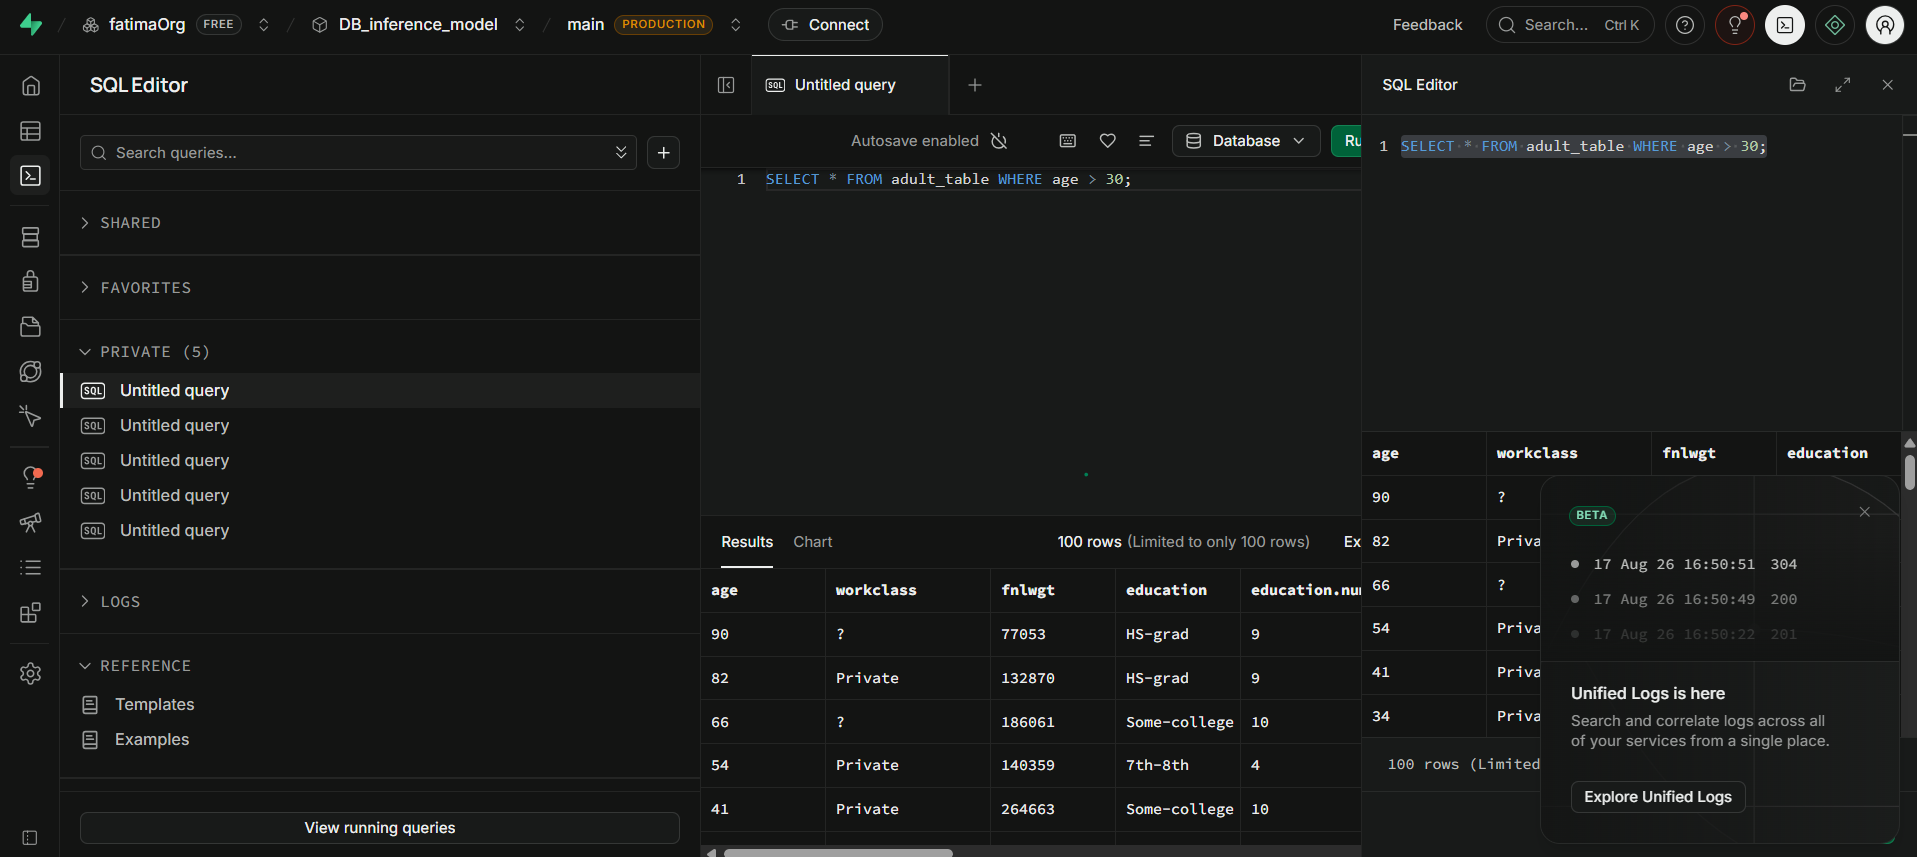

**Task 10**

In [65]:
df.shape

(32561, 15)

There are a total of 32561 rows, and 15 columns. The dataset represents different factors that can potentially affect someone's income. Basically there are a bunch of features that determine the target outcome which is the income column. Overall the data quality is decent, with only 3 categorical columns having missing values, and even then only a few thousand rows have missing values out of the total 32561 rows.

The notable pattern is that this data shows that 75 percent of the sample data earn less than 50k. And that the data is a bit leaning towards men, as 66 percent of the data comes from the men.

I didnt drop any column, but i did modify missing values for workclass and occupation by filling the workclass with mode and the occupation with Unknown as occupation can be more specific.